## Linear Correlation
## Phase 1: Sanity Checks (before any statistics)
Class balance — if severe imbalance (>80/20), your correlation estimates are biased downward
Sample size per feature — rule of thumb: n > 20 per feature minimum for stable correlations
Data types — confirm no ordinal-encoded categoricals are being treated as continuous


## Phase 2: Univariate Screening
Point-biserial r for every feature. This is your first filter.
Side-analyses:

Plot distribution of |r| — is there a natural elbow, or is everything noise?
Flag features with |r| > 0.1 as candidates (domain-dependent threshold)


## Phase 3: Significance & Multiple Comparisons
Convert r → t → p-value, then apply Benjamini-Hochberg FDR correction (not Bonferroni — too conservative for correlated features).
Side-analyses:

Plot p-value histogram — under pure null it should be uniform; enrichment near 0 means real signal exists
Note: statistical significance ≠ practical significance; report both r and p


## Phase 4: Collinearity Audit
Among your surviving candidates, compute the feature-feature correlation matrix. Collinear features (|r| > 0.7) are redundant — keep the one with highest |r_pb| against target.
Side-analyses:

Cluster the correlation matrix (hierarchical, average linkage) — each cluster should yield at most one representative feature
This is where domain knowledge earns its keep


Phase 5: Effect Size Interpretation
For each surviving feature, compute:

Cohen's d — standardised mean difference between classes, interpretable independently of n
r² — variance explained, gives you the ceiling on predictive utility of that single feature

In [2]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
import category_encoders as ce

pd.set_option("display.max_columns", None)

DATA_PATH = Path("../data")

In [3]:
df = pd.read_parquet(DATA_PATH / "final_data.parquet")
df.columns

Index(['num_pit_stops', 'pit_1_lap', 'pit_2_lap', 'pit_3_lap',
       'pit_1_duration', 'pit_2_duration', 'pit_3_duration', 'pit_1_intime',
       'pit_2_intime', 'pit_3_intime', 'pit_1_fresh', 'pit_2_fresh',
       'pit_3_fresh', 'pit_1_tyre_before', 'pit_2_tyre_before',
       'pit_3_tyre_before', 'pit_1_tyre_after', 'pit_2_tyre_after',
       'pit_3_tyre_after', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
       'TrackTemp', 'WindDirection', 'WindSpeed', 'rain_start', 'rain_stop',
       'rain_start_time', 'rain_stop_time', 'max_temp', 'min_temp', 'avg_temp',
       'std_temp', 'total_laps', 'end_position', 'starting_position',
       'pit_4_lap', 'pit_5_lap', 'pit_4_duration', 'pit_5_duration',
       'pit_4_intime', 'pit_5_intime', 'pit_4_fresh', 'pit_5_fresh',
       'pit_4_tyre_before', 'pit_5_tyre_before', 'pit_4_tyre_after',
       'pit_5_tyre_after', 'pit_6_lap', 'pit_6_duration', 'pit_6_intime',
       'pit_6_fresh', 'pit_6_tyre_before', 'pit_6_tyre_after', 'pit_7_lap',
 

## Some Sanity Checks
- Class balance — if severe imbalance (>80/20), the correlation estimates are biased downward  
- Sample size per feature — rule of thumb: n > 20 per feature minimum for stable correlations  
- Data types — confirm no ordinal-encoded categoricals are being treated as continuous  



This isn't meant to tell us anything other than dataset balance. Using pandas `value_counts` and dividing by the number of records for each of our target (in this case, whether a driver won the race), we get an idea of how to read the univariate correlation estimates. If the imbalance is severe (80/20, 90/10), then the correlation estiamtes are biased downwards.

From the below, the "True" (won_race) value is about 95ish percent of the dataset, which makes sense, out of 20-24 drivers, only one can win a race for every race (for our race time period of 2020-2025, as we're ignoring historical F1 races where drivers shared cars, etc etc)

In [20]:
df.won_race.value_counts()/df.won_race.count()

won_race
False    0.947095
True     0.052905
Name: count, dtype: float64

## 1. Univariate Analysis

The first, and most basic thing I want to check is point biserial correlation (equivalent to Pearson correlation). This comes with a few assumptions:
- One of my variables is continuous (might run into some problems here) and the other is dichotomous 
- There are no outliers
- Continuous variables should be approximately normal (may need some feature transformations)
- The continuous variables should have equal variances for each category (this might be a problem, but we can verify using Levene's test)

In [70]:
# handling the numeric features alone at first
numeric_features_df = df.select_dtypes(exclude=['object','bool'])

# clip outliers to the 1st and 99th percentiles
numeric_features_clipped_df = numeric_features_df.clip(lower=numeric_features_df.quantile(0.01), upper=numeric_features_df.quantile(0.99), axis=1)

# normalize the numeric features
normalized_numeric_features = numeric_features_clipped_df.sub(numeric_features_clipped_df.mean()).div(numeric_features_clipped_df.std())

normalized_numeric_features['won_race'] = df['won_race'].astype(int)

normalized_numeric_features.drop(['end_position'], axis=1, inplace=True)

In [ ]:
# run 1!
statistic, pvalue = pointbiserialr(normalized_numeric_features.drop(['won_race'], axis=1), df[['won_race']].astype(int))

pd.DataFrame({'feature': normalized_numeric_features.drop(['won_race']), 'statistic': statistic, 'pvalue': pvalue}).sort_values(by='statistic', ascending=False).dropna(subset=['statistic'])

,feature,statistic,pvalue
36,pit_1_to_total,0.031812,1.626271e-01
1,pit_1_lap,0.026576,2.434703e-01
7,pit_1_intime,0.016178,4.777435e-01
4,pit_1_duration,0.009009,6.925937e-01
14,WindDirection,0.003747,8.693869e-01
13,TrackTemp,0.003076,8.926359e-01
21,std_temp,0.000993,9.652457e-01
10,AirTemp,0.000929,9.674883e-01
20,avg_temp,0.000918,9.678564e-01
18,max_temp,0.000820,9.713034e-01


This is the first run of this analysis, however there are some.....problems. Firstly, some races only had 1 pit stop, while others had more than one, this means that in the clip and normalization steps above, the races with more than one pit stop are ignored, this means we can either:
- create a flag for "more_than_1_pit_stop" or
- set the pit-stop features where missing to some numerical, unique value (try zero!!)   

In [102]:
numeric_features_df.loc[:, numeric_features_df.columns.str.contains('pit_')] = numeric_features_df.loc[:, numeric_features_df.columns.str.contains('pit_')].fillna(0)

# same as the above but with the pit stop features filled with -1s instead of being dropped
numeric_features_clipped_df = numeric_features_df.clip(lower=numeric_features_df.quantile(0.01), upper=numeric_features_df.quantile(0.99), axis=1)
normalized_numeric_features = numeric_features_clipped_df.sub(numeric_features_clipped_df.mean()).div(numeric_features_clipped_df.std())
normalized_numeric_features['won_race'] = df['won_race'].astype(int)
normalized_numeric_features.drop(['end_position'], axis=1, inplace=True)

statistic, pvalue = pointbiserialr(df[['won_race']].astype(bool), normalized_numeric_features.drop(['won_race'], axis=1))

pd.DataFrame({'feature': normalized_numeric_features.drop(['won_race'], axis=1).columns, 'statistic': statistic, 'statistic_norm': abs(statistic), 'pvalue': pvalue}).sort_values(by='statistic_norm', ascending=False).dropna(subset=['statistic'])

,feature,statistic,statistic_norm,pvalue
23,starting_position,-0.309789,0.309789,3.722313e-44
6,pit_3_duration,0.031857,0.031857,1.620333e-01
36,pit_1_to_total,0.031812,0.031812,1.626271e-01
1,pit_1_lap,0.026576,0.026576,2.434703e-01
26,pit_4_duration,-0.024975,0.024975,2.730395e-01
37,pit_2_to_total,0.019561,0.019561,3.906558e-01
2,pit_2_lap,0.017917,0.017917,4.316983e-01
7,pit_1_intime,0.016178,0.016178,4.777435e-01
28,pit_4_intime,-0.010738,0.010738,6.374940e-01
4,pit_1_duration,0.009009,0.009009,6.925937e-01


Some, new (?) things to note, I'm thinking there needs to be some way to natively handle NaN values in correlation analysis OR drop rows where the `pit_3_` features are non-nan. Intuitively, if a 3rd pit stop did happen, it in theory would have a negative impact on the occurency of a race win. However, the `pit_3_duration` here has a positive statistic. This either means that:
- If you had a 3rd pit stop, there was a higher chance of a race win (doesn't make sense) OR
- More likely than not, our imputation step isn't working

## Sanity Checks Ep II
Rough check to see if the average occurence of a win is highly correlated to the chance of a pit stop whos very little evidence for such:"

In [103]:
df.assign(had_3rd_pit_stop=df['pit_3_intime'].notna().astype(int)).groupby('had_3rd_pit_stop')['won_race'].mean()

had_3rd_pit_stop
0    0.053925
1    0.049676
Name: won_race, dtype: float64

Going further, and hand waving away some normality assumptions (do not do this), the p-value of the `pit_3_intime` does not seem to vary on a statistically significant basis with the `won_race` variable. What this implies is that the distribution of `pit_3_intime` for both race winners and non-winners may have been sampled from similar-ish enough distributions

In [104]:
from scipy.stats import ks_2samp

ks_2samp(
    df.query('won_race==True').pit_3_intime.dropna(),
    df.query('won_race==False').pit_3_intime.dropna()
)

KstestResult(statistic=np.float64(0.15849802371541502), pvalue=np.float64(0.5854761742846385), statistic_location=np.float64(6588.231), statistic_sign=np.int8(-1))

Doing some pretty graphing to check some stuff, we can see that a higher starting position (i.e.) a LOWER number, does indeed correlate with a higher likelihood of a race win (i.e. ending 1st).

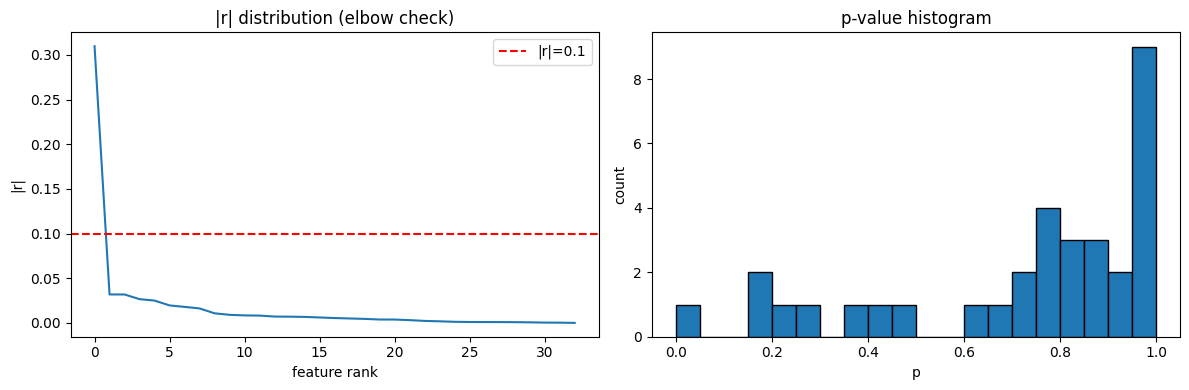

(              feature         r             p     abs_r
 23  starting_position -0.309789  3.722313e-44  0.309789
 6      pit_3_duration  0.031857  1.620333e-01  0.031857
 36     pit_1_to_total  0.031812  1.626271e-01  0.031812
 1           pit_1_lap  0.026576  2.434703e-01  0.026576
 26     pit_4_duration -0.024975  2.730395e-01  0.024975
 37     pit_2_to_total  0.019561  3.906558e-01  0.019561
 2           pit_2_lap  0.017917  4.316983e-01  0.017917
 7        pit_1_intime  0.016178  4.777435e-01  0.016178
 28       pit_4_intime -0.010738  6.374940e-01  0.010738
 4      pit_1_duration  0.009009  6.925937e-01  0.009009
 0       num_pit_stops -0.008375  7.132370e-01  0.008375
 15          WindSpeed -0.008169  7.199878e-01  0.008169
 29       pit_5_intime -0.007090  7.557000e-01  0.007090
 39     pit_4_to_total -0.006959  7.600701e-01  0.006959
 25          pit_5_lap -0.006707  7.685220e-01  0.006707
 40     pit_5_to_total -0.006069  7.899970e-01  0.006069
 27     pit_5_duration -0.00542

In [106]:
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from statsmodels.stats.multitest import multipletests


def phase2_3(df: pd.DataFrame, target: str, r_threshold: float = 0.1):
    features = [c for c in df.columns if c != target]
    y = df[target]

    # Phase 2: point-biserial r
    stats = pd.DataFrame(
        [(col, *pointbiserialr(y, df[col])) for col in features],
        columns=["feature", "r", "p"]
    ).assign(abs_r=lambda d: d.r.abs()).sort_values("abs_r", ascending=False)

    candidates = stats[stats.abs_r > r_threshold]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Elbow plot
    ax1.plot(range(len(stats)), stats.abs_r.values)
    ax1.axhline(r_threshold, color="red", linestyle="--", label=f"|r|={r_threshold}")
    ax1.set(title="|r| distribution (elbow check)", xlabel="feature rank", ylabel="|r|")
    ax1.legend()

    
    # p-value histogram
    ax2.hist(stats.p, bins=20, edgecolor="black")
    ax2.set(title="p-value histogram", xlabel="p", ylabel="count")

    plt.tight_layout()
    plt.show()

    return stats, candidates

phase2_3(normalized_numeric_features, target='won_race')

## Dropping Higher Than 3 Pit Stops Features

Alright, so that still sort-of-makes-sense for certain features, but let's explore a bit further, since setting those missing values to `0` was quite neanderthalic. Instead, I'm going to drop altogether the `pit_3` and above features, and set them to new boolean variables i.e. `had_3_pit`, or even something like `had_more_than_2_pit`, since more than 2 pit stops tend to be rare unless weather conditions are highly variable OR there are a number of safety cars (both counting as "extreme" events).

In [115]:
# handling the numeric features alone at first
numeric_features_df = df.select_dtypes(exclude=['object','bool'])

numeric_features_df = numeric_features_df.assign(had_more_than_2_pit=lambda x: x.pit_3_duration.notna().astype(int)).drop(numeric_features_df.loc[:, numeric_features_df.columns.str.contains('pit_3')].columns, axis=1)
# same as the above but with the pit stop features filled with -1s instead of being dropped
numeric_features_clipped_df = numeric_features_df.clip(lower=numeric_features_df.quantile(0.01), upper=numeric_features_df.quantile(0.99), axis=1)
normalized_numeric_features = numeric_features_clipped_df.sub(numeric_features_clipped_df.mean()).div(numeric_features_clipped_df.std())
normalized_numeric_features['won_race'] = df['won_race'].astype(int)
normalized_numeric_features.drop(['end_position'], axis=1, inplace=True)

statistic, pvalue = pointbiserialr(df[['won_race']].astype(bool), normalized_numeric_features.drop(['won_race'], axis=1))

pd.DataFrame({'feature': normalized_numeric_features.drop(['won_race'], axis=1).columns, 'statistic': statistic, 'statistic_norm': abs(statistic), 'pvalue': pvalue}).sort_values(by='statistic_norm', ascending=False).dropna(subset=['statistic'])

,feature,statistic,statistic_norm,pvalue
20,starting_position,-0.309789,0.309789,3.722313e-44
33,pit_1_to_total,0.031812,0.031812,1.626271e-01
1,pit_1_lap,0.026576,0.026576,2.434703e-01
5,pit_1_intime,0.016178,0.016178,4.777435e-01
3,pit_1_duration,0.009009,0.009009,6.925937e-01
0,num_pit_stops,-0.008375,0.008375,7.132370e-01
12,WindSpeed,-0.008169,0.008169,7.199878e-01
39,had_more_than_2_pit,-0.008108,0.008108,7.219860e-01
11,WindDirection,0.003747,0.003747,8.693869e-01
10,TrackTemp,0.003076,0.003076,8.926359e-01


This seems to help, and it also shows the second most correlated feature is when the first pit stop occured (along with `pit_1_lap`), which sort of measures the same thing. This brings up another interesting point, several of these features in theory are highly correlated (e.g. a higher `pit_1_to_total` by definition is correlated near linearly with `pit_1_lap`), and this is somewhat verified using a basic `.corr()` between both columns, the value is about 0.65, not fully correlated, but definitely stretching the bounds of what I'd consider independent. 

In [121]:
abs(numeric_features_df[['pit_1_lap', 'pit_1_intime']].corr())

,pit_1_lap,pit_1_intime
pit_1_lap,1.000000,0.642321
pit_1_intime,0.642321,1.000000


In order to address this potential multi-collinearity, variance-inflation-factor is used; This measures the strength of correlation between (in theory) independent variables in regression analysis. Using the rule of thumb that `vif>3` is generally unacceptable:

In [140]:
def select_by_vif(X: pd.DataFrame, y: pd.Series, threshold: float = 5.0) -> list:
    cols = list(X.columns)
    scores = pd.Series({c: abs(pointbiserialr(y, X[c]).statistic) for c in cols})
    while True:
        vif = pd.Series(
            [variance_inflation_factor(add_constant(X[cols]).values, i) for i in range(len(cols))],
            index=cols
        )
        if vif.max() < threshold:
            break
        cols.remove(scores[vif[vif >= threshold].index].idxmin())
    return cols


only_non_collinear = select_by_vif(normalized_numeric_features.drop([
    'won_race'
], axis=1).fillna(0), normalized_numeric_features['won_race'], threshold=2)

print(only_non_collinear)

/home/aadi/projects/f1-finishing-position/.venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/aadi/projects/f1-finishing-position/.venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/aadi/projects/f1-finishing-position/.venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/aadi/projects/f1-finishing-position/.venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/aadi/projects/f1-finishing-position/.venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide

['num_pit_stops', 'pit_1_lap']


In theory, this should give us the most robust predictors of a race win; However there's a caveat, by definition `pit_1` is going to happen before `pit_2` which happens before `pit_3`. So saying the lap at which the first pit stop happens and the number of pit stops which occurred are the two, single most important predictors of a race win (even ignoring race start position) is a heavy dose of mixing up correlation for causation (in my opinion!!).

I'm thinking some slightly more intelligent feature-engineering here should help:

In [155]:
# firstly, lets's create features for pit_2_intime and pit_3_intime relative to pit_1_intime and pit_2_intime respectively

df['pit_2_intime_rel'] = df['pit_2_intime'] - df['pit_1_intime']
df['pit_3_intime_rel'] = df['pit_3_intime'] - df['pit_2_intime']
# numeric_features_df['pit_3_intime_rel'] = numeric_features_df['pit_3_intime'] - numeric_features_df['pit_2_intime']


numeric_features_df = df.select_dtypes(exclude=['object','bool'])

# clip outliers to the 1st and 99th percentiles
numeric_features_clipped_df = numeric_features_df.clip(lower=numeric_features_df.quantile(0.01), upper=numeric_features_df.quantile(0.99), axis=1)

# normalize the numeric features
normalized_numeric_features = numeric_features_clipped_df.sub(numeric_features_clipped_df.mean()).div(numeric_features_clipped_df.std())

normalized_numeric_features['won_race'] = df['won_race'].astype(int)

normalized_numeric_features.drop(['end_position', 'pit_1_intime', 'pit_2_intime', 'pit_3_intime'], axis=1, inplace=True)


select_by_vif(normalized_numeric_features.drop(['won_race'], axis=1).fillna(0), normalized_numeric_features['won_race'], threshold=3)

/home/aadi/projects/f1-finishing-position/.venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/aadi/projects/f1-finishing-position/.venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/aadi/projects/f1-finishing-position/.venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/aadi/projects/f1-finishing-position/.venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/aadi/projects/f1-finishing-position/.venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide

['num_pit_stops', 'pit_1_lap']

This is interesting, it means that there are columns in the data which show some sort of linear correlation, exploring more using a heatmap, and dropping features relating to more than 3 pit-stops. Also taking the liberty to drop one of each of the following:
- [AirTemp, TrackTemp] (dropping AirTemp)
- [Pressure, Humidity] (dropping Pressure)
- [WindDirection, WindSpeed] (dropping both, without more context about the track this doesn't tell us much)
- [rain_start_time, rain_stop_time] (dropping both of these as well, we have other indicators telling us when tires were changed etc)
- [max_temp, min_temp] (dropping both in favour of `avg_temp` and `std_temp` which in theory capture the same thing)
- All the absolute `pit_1` and `pit_2` features (`pit_1_lap, pit_2_lap, pit_1_intime, pit_2_intime')


Some interesting (unexpected?) things to note from here:
- The duration of the first pit stop is somehow correlated to the time taken from the first pit stop to the second? I have no explanation for this one unless cars are stacked, but in this case each row accounts for a different driver
- Same for the duration of the second pit stop when compared to when the 3rd pit stop occured relative to the second. 

Less interesting:
- The pit_3_intime_rel to pit_1_to_total makes sense, if the first pit is later, on most occasions the third pit stop would be later if it occurs.
- Number of pit stops is correlated to when the first pit stop occurs, less pit stops meant that on average, the first pit stop tended to occur later. 

<Axes: >

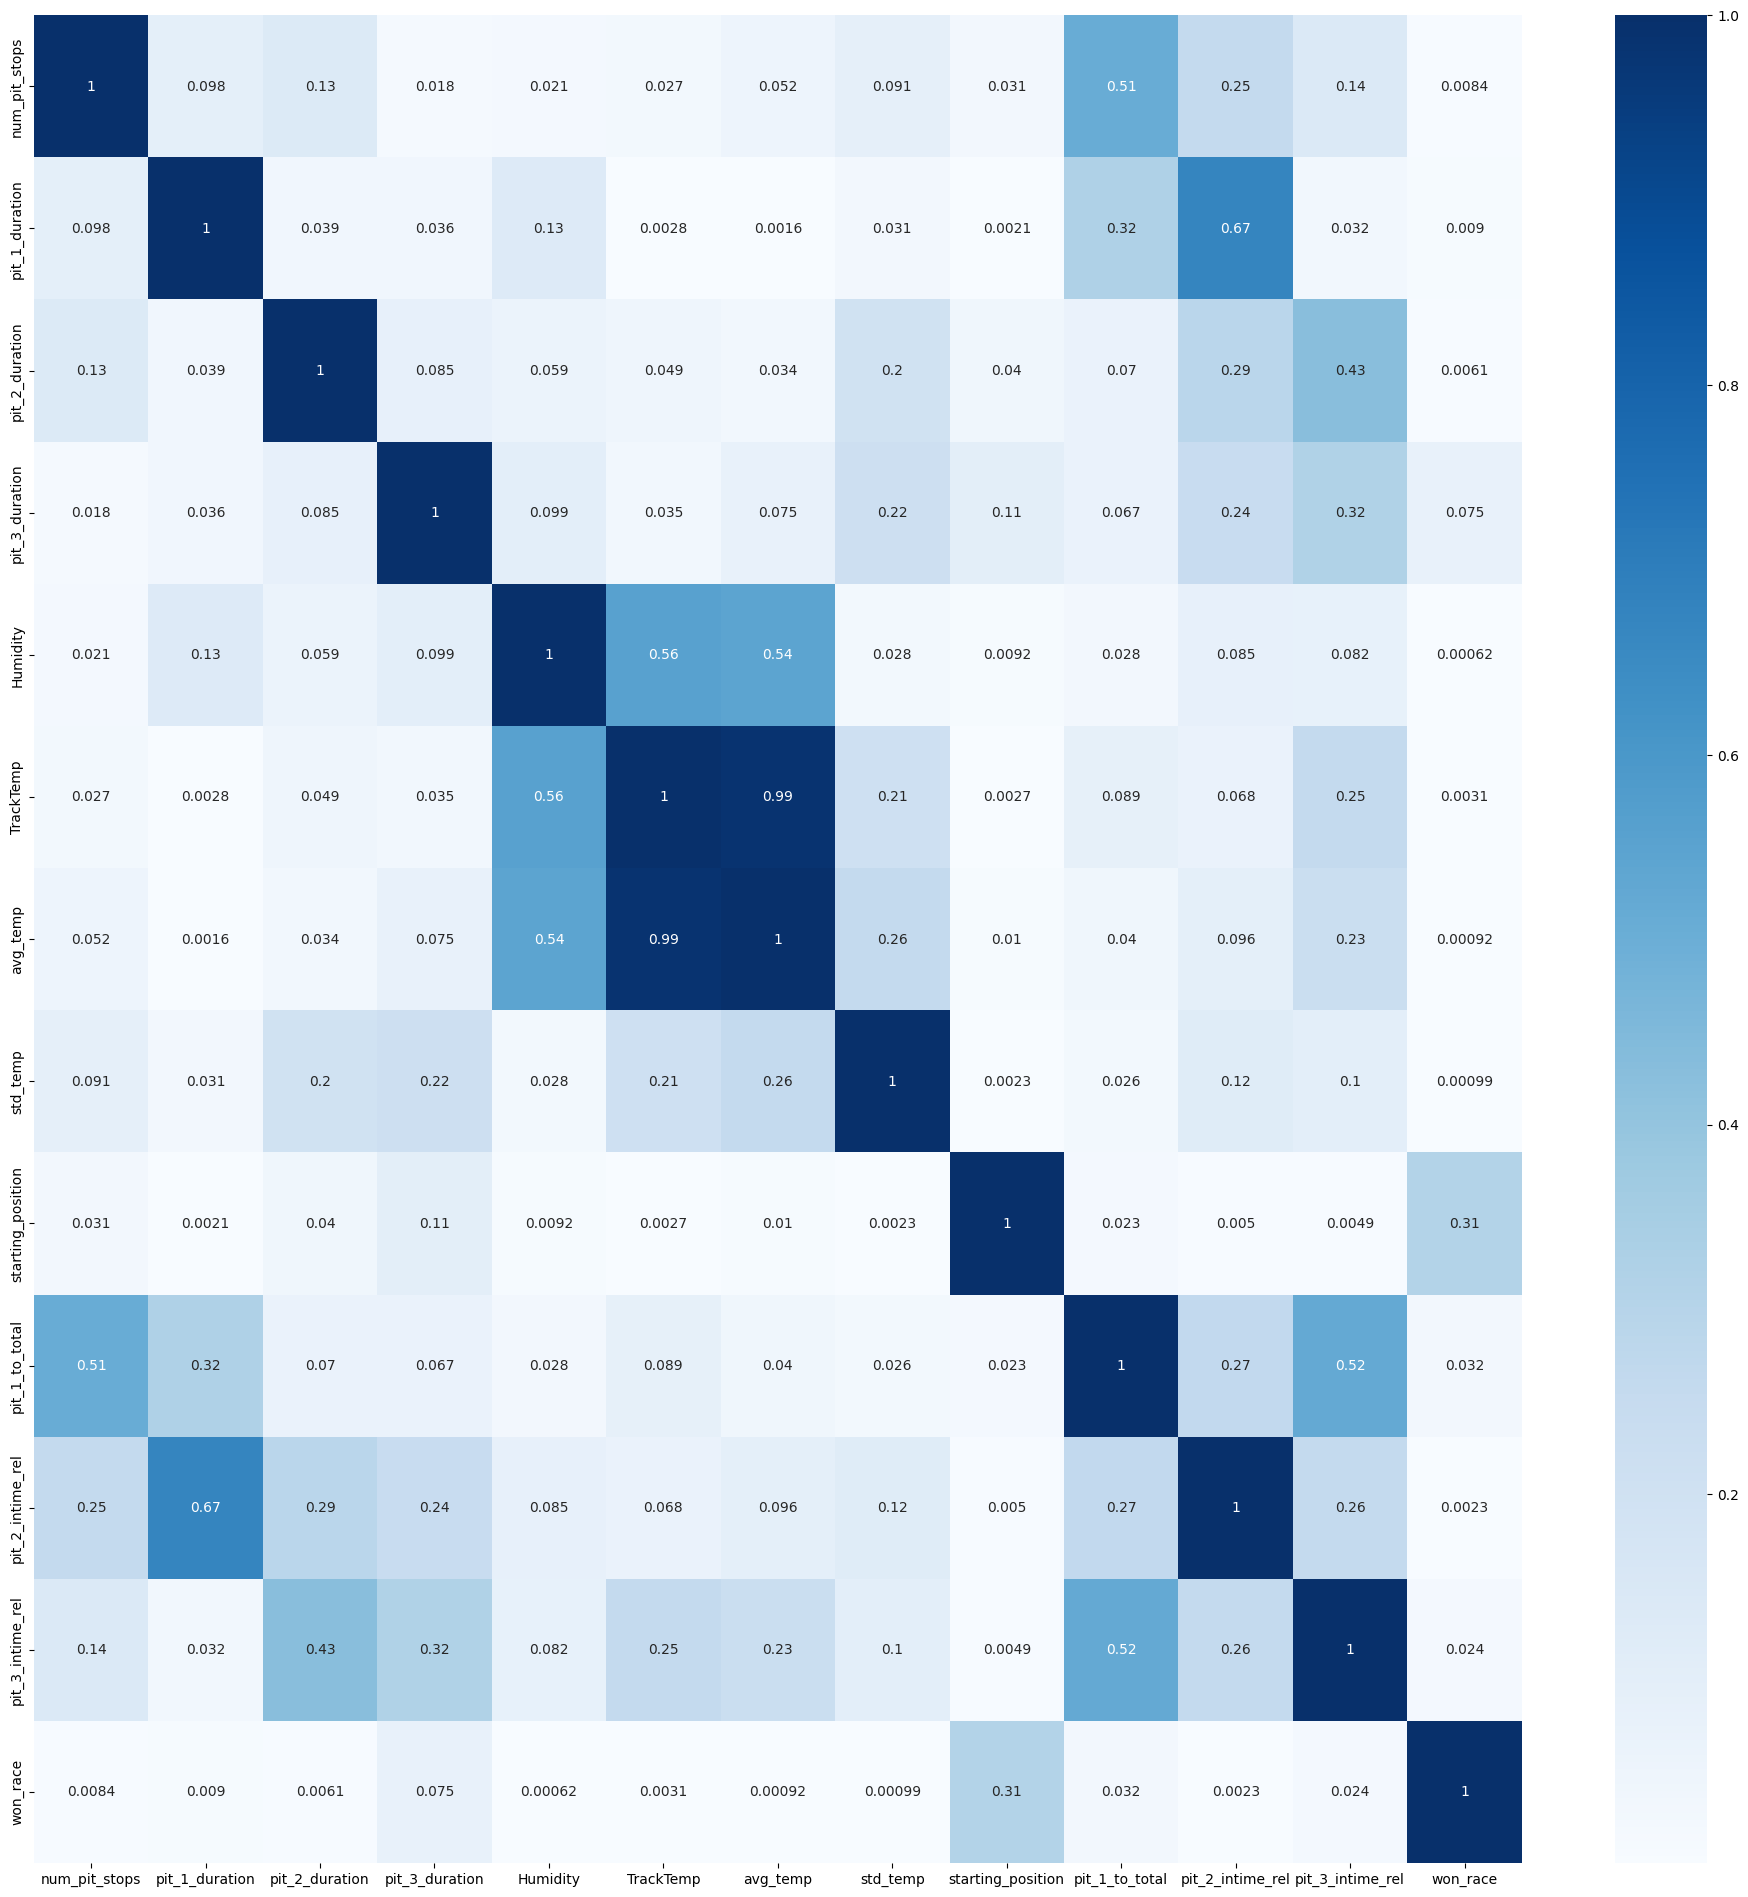

In [186]:
import seaborn as sb

MANUAL_DROP = [
    'AirTemp',
    'Pressure',
    'WindDirection', 'WindSpeed',
    'rain_start_time','rain_stop_time',
    'max_temp','min_temp',
    'pit_1_lap', 'pit_2_lap', 'pit_3_lap','pit_4_lap', 'pit_5_lap', 'pit_6_lap', 'pit_7_lap',
    'pit_2_to_total', 'pit_3_to_total', 'total_laps',
    'pit_4_duration',
 'pit_5_duration',
 'pit_6_duration',
 'pit_7_duration',
 'pit_4_intime',
 'pit_5_intime',
 'pit_6_intime',
 'pit_7_intime',
 'pit_6_duration',
 'pit_4_to_total',
 'pit_5_to_total',
 'pit_6_to_total',
 'pit_7_to_total',
]

corr = normalized_numeric_features.drop(MANUAL_DROP, axis=1).corr()

fig, ax = plt.subplots(figsize=(24,24))   
sb.heatmap(corr.abs(), cmap="Blues", annot=True, ax=ax)

Trying back this again, and selecting out only singlets from each of other correlated pairs yields slightly more manageable results:

In [187]:
select_by_vif(normalized_numeric_features.drop(MANUAL_DROP + ['pit_2_intime_rel', 'pit_3_intime_rel', 'pit_4_lap', 'pit_5_lap'] + ['won_race'], axis=1).fillna(0), normalized_numeric_features['won_race'], threshold=3)

['num_pit_stops',
 'pit_1_duration',
 'pit_2_duration',
 'pit_3_duration',
 'Humidity',
 'TrackTemp',
 'std_temp',
 'starting_position',
 'pit_1_to_total']

## Effect Sizes!

Now we have a slightly more manageable set of features, let's compute effect sizes and Cohen's d, which would give us the standardized mean difference between classes, irrespective of the number of samples. Using the rule of thumb that anything larger than 0.8 (in absolute terms) is significant, and anything between 0.3ish and 0.8 is non-trivial:

In [193]:
import numpy as np

def effect_sizes(X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    rows = []
    for c in X.columns:
        x0, x1 = X[c][y==0], X[c][y==1]
        pooled_std = np.sqrt(((len(x0)-1)*x0.var() + (len(x1)-1)*x1.var()) / (len(y)-2))
        r = pointbiserialr(y, X[c]).statistic
        rows.append({"feature": c, "cohen_d": (x1.mean()-x0.mean())/pooled_std, "r2": r**2})
    return pd.DataFrame(rows).set_index("feature")


effect_sizes(normalized_numeric_features.drop(MANUAL_DROP + ['won_race'], axis=1), normalized_numeric_features['won_race']).sort_values(by='cohen_d', ascending=False)

,cohen_d,r2
feature,,
pit_3_duration,0.344295,NaN
pit_1_to_total,0.142117,1.012018e-03
pit_3_intime_rel,0.108749,NaN
pit_1_duration,0.040229,8.116622e-05
TrackTemp,0.013734,9.460764e-06
pit_2_intime_rel,0.010198,NaN
std_temp,0.004434,9.859816e-07
avg_temp,0.004100,8.433336e-07
Humidity,0.002753,3.801207e-07


# Sort-of-Conclusions
- From the above, we can say that the `pit_1_to_total` is fairly correlated with the `won_race`.  The reason why (I think) Cohen's d statistic isn't higher is due to the fact that winning from (e.g.) position 14 is harder than winning from position 2, so although starting and finishing positions may be correlated, the race **win** might be less 2. However, it's interesting that earlier pit stops do show slight correlation with our target, and again the actual relation may be limited by the fact that we are measuring purely linear relationships here.
- The duration of the first pit stop may be correlated, less so, by the abysmal statistic, from a linear position.
- Why did I include average temperature and humidity? I don't know, in hindsight this should be on average the same for all cars, and any relation to the target would be spurious, again sort of confirmed by the very VERY low `cohen_d` column. 
- Number of pit stops, less correlated with the finishing position (again, disclaimer about exploring purely linear relationships here), but from an intuitive sense, the less pit stops means more time on the track and less time lost to stopping for a change of tires (hence the negative `cohen_d`.)
- Finally, the big (obvious) one, starting position, higher you start, higher you finish